# HOM-Only Dataset Plots

This notebook only reads generated CSV files. It does not run simulations. Use it after the Blackbird dataset generation finishes and the final combine step writes the CSV tables.

In [2]:

from pathlib import Path
import json
import configparser

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4)
pd.set_option('display.max_columns', 120)


def find_package_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for root in candidates:
        p = root / 'example' / 'hom_validation' / 'ai_hom_dataset'
        if (p / 'configs' / 'hom_ai_dataset_config.ini').exists():
            return p
        if (root / 'configs' / 'hom_ai_dataset_config.ini').exists():
            return root
    raise FileNotFoundError('Could not locate ai_hom_dataset package directory')

PACKAGE_DIR = find_package_dir()
CONFIG_PATH = PACKAGE_DIR / 'configs' / 'hom_ai_dataset_config.ini'

parser = configparser.ConfigParser(inline_comment_prefixes=('#', ';'), interpolation=None)
parser.read(CONFIG_PATH, encoding='utf-8-sig')
DATASET_NAME = parser.get('generation', 'dataset_name', fallback='hom_ai_dataset_sample')
configured_output = parser.get('slurm', 'output_dir', fallback='').strip()
DATASET_DIR = Path(configured_output) if configured_output else PACKAGE_DIR / 'generated' / DATASET_NAME

SAVE_PLOTS = True
PLOTS_DIR = PACKAGE_DIR.parent / 'plots' / 'hom_dataset_plots' / DATASET_NAME

def save_pdf(fig, name: str) -> Path | None:
    if not SAVE_PLOTS:
        return None
    path = PLOTS_DIR / f'{name}.pdf'
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, format='pdf', bbox_inches='tight')
    print('Saved plot:', path)
    return path

print(f'Package dir: {PACKAGE_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print(f'PDF output: {PLOTS_DIR}')


def require_file(name: str) -> Path:
    path = DATASET_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Generate the dataset first, or update DATASET_DIR.')
    return path


def load_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(require_file(name))


Package dir: c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-ai-dataset\example\hom_validation\ai_hom_dataset
Dataset dir: c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-ai-dataset\example\hom_validation\ai_hom_dataset\generated\hom_ai_dataset_60s_10k_blackbird


In [3]:

observable = load_csv('hom_observable_windows.csv')
labels = load_csv('episode_labels.csv')
truth = load_csv('hidden_truth.csv')
summary = load_csv('validation_summary.csv')
metadata = json.loads(require_file('metadata.json').read_text(encoding='utf-8'))

PLOT_SAMPLE_PER_CLASS = 20_000
plot_samples = []
for _, group in observable.groupby('fault_class', sort=True):
    plot_samples.append(group.sample(min(len(group), PLOT_SAMPLE_PER_CLASS), random_state=7))
observable_plot = pd.concat(plot_samples, ignore_index=True)

print(metadata)
print('observable rows:', len(observable))
print('plot rows:', len(observable_plot))
print('episodes:', len(labels))
print('fault classes:', sorted(labels['fault_class'].unique()))
observable.head()


{'created_at': '2026-06-13T13:49:45.237148', 'config_path': 'example/hom_validation/ai_hom_dataset/configs/hom_ai_dataset_config.ini', 'labels': ['healthy', 'temperature_drift', 'polarization_drift', 'spectral_detuning', 'raman_noise', 'attenuation_loss', 'source_brightness_loss', 'sync_issue', 'source_clock_drift'], 'dataset_name': 'hom_ai_dataset_60s_10k_blackbird', 'dataset_size': 10000, 'episodes': 10000, 'windows': 600000, 'episode_duration_s': 60.0, 'window_duration_s': 1.0, 'hom_only': True, 'ai_input_file': 'hom_observable_windows.csv', 'label_file': 'episode_labels.csv', 'hidden_truth_file': 'hidden_truth.csv', 'setup_params_file': 'setup_params.csv', 'validation_summary_file': 'validation_summary.csv', 'raw_streams_enabled': False, 'elapsed_s': 203.2408709526062, 'note': 'AI inputs are HOM-only. Hidden truth contains simulator-only labels and must not be used as operational input.'}
observable rows: 600000
plot rows: 180000
episodes: 10000
fault classes: ['attenuation_loss', 

,episode_id,setup_id,fault_class,window_index,window_start_s,window_end_s,window_duration_s,fault_active,hom1_count,hom2_count,hom1_rate_hz,hom2_rate_hz,hom_singles_sum_rate_hz,hom_twofold_count,hom_twofold_rate_hz,peak_position_ps,peak_width_ps,peak_height,peak_snr,coincidence_count_hist,accidental_count_estimate,accidental_rate_hz,car,hom1_interarrival_mean_ps,hom1_interarrival_std_ps,hom1_interarrival_min_ps,hom1_interarrival_max_ps,hom2_interarrival_mean_ps,hom2_interarrival_std_ps,hom2_interarrival_min_ps,hom2_interarrival_max_ps,delta_hom1_rate_hz,delta_hom2_rate_hz,delta_hom_twofold_rate_hz,delta_peak_position_ps,delta_peak_width_ps,delta_peak_snr,delta_car,delta_accidental_rate_hz
0,attenuation_loss_00009,hom_reference_40km,attenuation_loss,0,0.0,1.0,1.0,0,403387,404808,403387.0,404808.0,808195.0,1522,1522.0,10.0,100.0,378.0,251.313351,1524,18.049180,18.049180,84.435967,2.491297e+06,2.515206e+06,0.0,68786323.0,2.482652e+06,2.498900e+06,0.0,59257843.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,attenuation_loss_00009,hom_reference_40km,attenuation_loss,1,1.0,2.0,1.0,0,404796,405036,404796.0,405036.0,809832.0,1464,1464.0,10.0,100.0,365.0,264.272997,1474,16.573770,16.573770,88.935707,2.482682e+06,2.517769e+06,0.0,58630846.0,2.481195e+06,2.506940e+06,0.0,57150839.0,1409.0,228.0,-58.0,0.0,0.0,12.959646,4.499740,-1.475410
2,attenuation_loss_00009,hom_reference_40km,attenuation_loss,2,2.0,3.0,1.0,0,405506,404822,405506.0,404822.0,810328.0,1374,1374.0,10.0,100.0,330.0,217.621622,1377,18.196721,18.196721,75.672973,2.478336e+06,2.497905e+06,0.0,50117621.0,2.482549e+06,2.511885e+06,0.0,63828211.0,710.0,-214.0,-90.0,0.0,0.0,-46.651375,-13.262734,1.622951
3,attenuation_loss_00009,hom_reference_40km,attenuation_loss,3,3.0,4.0,1.0,0,404607,404508,404607.0,404508.0,809115.0,1479,1479.0,-10.0,100.0,348.0,244.351079,1485,17.090164,17.090164,86.892086,2.483810e+06,2.509238e+06,0.0,62844940.0,2.484427e+06,2.510179e+06,0.0,61849440.0,-899.0,-314.0,105.0,-20.0,0.0,26.729458,11.219113,-1.106557
4,attenuation_loss_00009,hom_reference_40km,attenuation_loss,4,4.0,5.0,1.0,0,405414,404311,405414.0,404311.0,809725.0,1482,1482.0,-10.0,100.0,340.0,241.865889,1488,16.868852,16.868852,88.209913,2.478915e+06,2.502429e+06,0.0,50520054.0,2.485652e+06,2.514820e+06,0.0,62172612.0,807.0,-197.0,3.0,0.0,0.0,-2.485190,1.317826,-0.221311


## Dataset Composition

Checks whether each fault class has the expected number of episodes and windows.

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels['fault_class'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#396a93')
axes[0].set_title('Episodes per fault class')
axes[0].set_ylabel('Episodes')
axes[0].tick_params(axis='x', rotation=45)

observable.groupby('fault_class')['window_index'].count().sort_index().plot(kind='bar', ax=axes[1], color='#8b5e34')
axes[1].set_title('Windows per fault class')
axes[1].set_ylabel('Windows')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
save_pdf(fig, '01_dataset_class_balance')
plt.show()


## HOM Observable Distributions

These are AI-visible measurements only: HOM rates, HOM lag histogram peak, SNR, and CAR.

In [5]:

features = [
    'hom_twofold_rate_hz',
    'hom_singles_sum_rate_hz',
    'peak_position_ps',
    'peak_width_ps',
    'peak_snr',
    'car',
    'accidental_rate_hz',
]
features = [f for f in features if f in observable.columns]

plot_frame = observable_plot if 'fault_class' in observable_plot.columns else observable
grouped_plot = list(plot_frame.groupby('fault_class', sort=True))
names = [name for name, _ in grouped_plot]

ncols = 2
nrows = int(np.ceil(len(features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows))
axes = np.array(axes).reshape(-1)
for ax, feature in zip(axes, features):
    data = [group[feature].dropna().to_numpy() for _, group in grouped_plot]
    ax.boxplot(data, labels=names, showfliers=False)
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)
for ax in axes[len(features):]:
    ax.axis('off')
plt.tight_layout()
save_pdf(fig, '02_feature_distributions_by_fault_class')
plt.show()


## Pre/Post Fault Change Summary

Uses `validation_summary.csv`: each row compares windows before fault onset to windows after onset.

In [6]:

delta_cols = [c for c in summary.columns if c.startswith('delta_')]
important = [
    'delta_hom_twofold_rate_hz',
    'delta_hom1_rate_hz',
    'delta_hom2_rate_hz',
    'delta_peak_position_ps',
    'delta_peak_snr',
    'delta_car',
    'delta_accidental_rate_hz',
]
important = [c for c in important if c in summary.columns]
change = summary.groupby('fault_class')[important].mean().sort_index()
change


,delta_hom_twofold_rate_hz,delta_hom1_rate_hz,delta_hom2_rate_hz,delta_peak_position_ps,delta_peak_snr,delta_car,delta_accidental_rate_hz
fault_class,,,,,,,
attenuation_loss,-453.722637,-56561.762734,-56560.337230,-0.131959,-44.997804,-15.603520,-2.766816
healthy,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
polarization_drift,-0.046215,7.776052,3.983808,0.175784,0.220328,0.000842,0.000886
raman_noise,259.038173,656707.418611,656744.574819,0.067329,-216.273249,-73.939687,259.467996
source_brightness_loss,-594.300048,-79145.510960,-79159.778579,-0.211945,-60.313026,-20.392226,-3.863091
source_clock_drift,-193.652676,345.273226,348.072560,-0.084748,-87.129874,-29.384199,8.325717
spectral_detuning,237.182956,108.538279,118.632551,0.121822,43.324523,13.762244,0.015644
sync_issue,-1391.029659,2.596227,4.504041,-708.382665,-242.729137,-83.327272,27.370101
temperature_drift,-213.700452,348.919408,360.782141,-0.168346,-96.220139,-31.324401,8.701869


In [7]:

if important:
    fig, axes = plt.subplots(len(important), 1, figsize=(11, 3.2 * len(important)))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, important):
        change[col].plot(kind='bar', ax=ax, color='#4c6f57')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    save_pdf(fig, '03_pre_post_fault_feature_changes')
    plt.show()


## Representative Episodes

One example episode per class. Dashed line marks the fault onset window. Healthy has no real onset.

In [8]:

plot_features = [f for f in ['hom_twofold_rate_hz', 'peak_position_ps', 'peak_snr', 'car'] if f in observable.columns]
classes = sorted(labels['fault_class'].unique())

for fault_class in classes:
    episode_id = labels.loc[labels['fault_class'] == fault_class, 'episode_id'].iloc[0]
    ep = observable[observable['episode_id'] == episode_id].sort_values('window_index')
    label_row = labels[labels['episode_id'] == episode_id].iloc[0]
    x = ep['window_index']
    fig, axes = plt.subplots(len(plot_features), 1, figsize=(11, 2.8 * len(plot_features)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, feature in zip(axes, plot_features):
        ax.plot(x, ep[feature], marker='o')
        ax.axvline(label_row['fault_onset_window'], color='red', linestyle='--', alpha=0.6)
        ax.set_ylabel(feature)
    axes[0].set_title(f'{fault_class}: {episode_id}')
    axes[-1].set_xlabel('Window index')
    plt.tight_layout()
    save_pdf(fig, f'04_episode_traces/{fault_class}_{episode_id}')
    plt.show()


## Temperature Drift On Simulation Time Axis

This uses hidden truth only for validation. Do not use hidden truth as AI input.

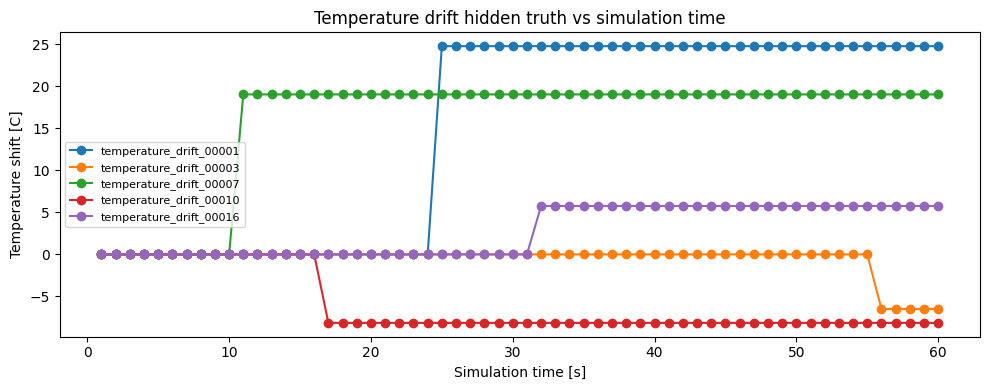

In [9]:

if 'temperature_change' in truth['fault_class'].unique():
    temp_eps = truth[truth['fault_class'] == 'temperature_change']['episode_id'].drop_duplicates().head(5)
    fig, ax = plt.subplots(figsize=(10, 4))
    for episode_id in temp_eps:
        t = truth[truth['episode_id'] == episode_id].sort_values('window_index')
        obs = observable[observable['episode_id'] == episode_id].sort_values('window_index')
        sim_seconds = obs['window_end_s'].to_numpy()
        ax.plot(sim_seconds, t['true_temperature_shift_c'], marker='o', label=episode_id)
    ax.set_title('Temperature drift hidden truth vs simulation time')
    ax.set_xlabel('Simulation time [s]')
    ax.set_ylabel('Temperature shift [C]')
    ax.legend(fontsize=8)
    plt.tight_layout()
    save_pdf(fig, '05_temperature_hidden_truth')
    plt.show()
else:
    print('No temperature_change episodes found.')
